## Libraries

In [1]:
from pathlib import Path
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import random
import tensorflow as tf
from tensorflow import keras
from keras import layers

print(f"Tensorflow {tf.__version__}")
print(f"Keras {keras.__version__}")

Tensorflow 2.17.1
Keras 3.13.2


## Dataset

This first cell defines some path names.

In [2]:
# Path where the dataset is stored
data_dir = "/Users/tv/librispeech" ## CHANGE THIS

# See the website linked below for available splits
train_name = "train-clean-100"
test_name = "test-clean"
dev_name = "dev-clean"

# DON'T CHANGE
sample_rate = 16000 # DON'T CHANGE

### Download

The following cell downloads the sets defined above (in `train_name`, `test_name` and `dev_name`) into `data_dir`,
from <https://www.openslr.org/12>.

The downloaded archive is structured like `LibriSpeech/<dataset>/<speaker>/<chapter>/<file>.flac`. This function also takes care to encode
and reorganize that into `<dataset>/<speaker>/<file>.wav` (we don't care about chapter structure).

In [3]:
# Check dependencies
import shutil
for requirement in ["curl", "tar", "grep", "ffmpeg"]:
    if not shutil.which(requirement):
        raise f"Dependency {requirement} not found!"

def ensure_set(name: str):
    """Ensures that a split of LibriSpeech is available."""
    
    basepath = Path(data_dir)
    # Expected directory for this split
    set_dir = basepath.joinpath(name)
    # Archive path
    tar = basepath.joinpath(name + ".tar.gz")
    # Ensure the main data directory exists
    basepath.mkdir(exist_ok=True, parents=True)

    if set_dir.exists():
        print(f"Set {name} already found")
        return

    # Download provided archive from the web using cURL
    if not tar.exists():
        print(f"Downloading LibriSpeech {name}...")
        url = "https://openslr.trmal.net/resources/12/" + name + ".tar.gz"
        !curl -Lo {tar.absolute()} {url}

    # Extract downloaded archive
    print(f"Extracting LibriSpeech {name}")
    set_dir.mkdir()
    # This grep pattern extracts the first-level directories after the split name,
    # which correspond to speaker IDs.
    # I❤️IPython
    speakers = !tar -tf {tar.absolute()} | grep '.*/'{name}'/[[:digit:]]*/$'
    for speaker in speakers:
        # Path to the speaker *within the archive*
        sp_in_tar = Path(speaker)
        # Path to the speaker directory
        speaker_dir = set_dir.joinpath(sp_in_tar.name)
        speaker_dir.mkdir()
        
        print(f"Extracting speaker {sp_in_tar.name}")
        # This pattern extracts all .flac files from the speaker directory
        # --strip-components 4 is used to remove leading directories (chapter information etc.)
        # as we already make sure the files are extracted to the speaker directory using -C
        !tar -C {speaker_dir.absolute()} --strip-components 4 -xzf {tar.absolute()} {sp_in_tar}'/**/*.flac'

        # WAV Conversion, also ensures the sample rate is correct
        for sample in speaker_dir.glob("*.flac"):
            !ffmpeg -loglevel error -y -i {sample.absolute()} -ar {sample_rate} {sample.with_suffix(".wav").absolute()}
            # Remove original .flac
            sample.unlink()

    # Remove archive
    tar.unlink()

print("Downloading dataset (LibriSpeech)")
ensure_set(train_name)
ensure_set(dev_name)
ensure_set(test_name)
print("Done!")

Set train-clean-100 already found
Set dev-clean already found
Set test-clean already found
Done!


### Setup

In [4]:
# Crop audio file to the correct length (randomly)
def read_and_crop(file, length_samples, seed=None):
    # Decode audio file
    audio_bin = tf.io.read_file(file)
    audio, _ = tf.audio.decode_wav(audio_bin)

    # Pad if necessary
    audio_length = tf.shape(audio)[0]
    pad_length = tf.maximum(0, length_samples - audio_length)
    # Also remove the unnecessary channel dimension (in LibriSpeech always 1)
    audio = tf.squeeze(tf.pad(audio, [[0, pad_length], [0, 0]]))

    return tf.image.random_crop(audio, size=[length_samples], seed=seed)

# Traverse directory structure to generate dataset for a Siamese network with contrastive loss
def ds_for_siamese_network(directory, length_samples, batch_size=32, max_pairs_per_speaker=1000, seed=None):
    if seed:
        random.seed(seed)
        tf.random.set_seed(seed)

    directory = Path(directory)

    # First-level directories correspond to speakers
    speaker_dirs = [d for d in directory.glob("*") if d.is_dir()]
    # Map of speaker name => file list
    speaker_to_files = {}

    # Populate speaker_to_files
    for d in speaker_dirs:
        files = [str(p) for p in d.glob("*.wav")]
        if len(files) >= 2:
            speaker_to_files[d.name] = files
        else:
            print("Warning: discarding speaker", d.name)

    if not speaker_to_files: raise ValueError("Not enough data")

    # Python crashes if I don't do this
    speakers = list(speaker_to_files.keys())
    
    # This will become the actual dataset
    path_a_list = []
    path_b_list = []
    labels_list = [] # 1 - Same speaker, 0 - diff. speaker

    for speaker in speakers:
        files = speaker_to_files[speaker]
        positive_pairs = list(itertools.combinations(files, 2))
        random.shuffle(positive_pairs)

        # Truncate if necessary
        if max_pairs_per_speaker:
            positive_subset = positive_pairs[:max_pairs_per_speaker]
        else: positive_subset = positive_pairs

        # These are all positive pairs
        for file_a, file_b in positive_subset:
            path_a_list.append(file_a)
            path_b_list.append(file_b)
            labels_list.append(1)

            # Generate a negative pair, to ensure we have the same number
            # of positive and negative pairs.
            other_speaker = random.choice([s for s in speakers if s != speaker])
            negative_a = random.choice(files)
            negative_b = random.choice(speaker_to_files[other_speaker])
            path_a_list.append(negative_a)
            path_b_list.append(negative_b)
            labels_list.append(0)

    # Build dataset
    dataset = tf.data.Dataset.from_tensor_slices((path_a_list, path_b_list, labels_list))
    dataset = dataset.shuffle(buffer_size=len(labels_list), seed=seed)

    # Actually decode each file
    def process(path_a, path_b, label):
        return (read_and_crop(path_a, length_samples, seed=seed), read_and_crop(path_b, length_samples, seed=seed)), label

    return dataset.map(process, tf.data.AUTOTUNE).batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)


#### Log-Mel Spectrograms

The [mel scale](https://medium.com/analytics-vidhya/understanding-the-mel-spectrogram-fca2afa2ce53) maps frequencies to intervals close to humans perceive them (i.e. logarithmically).

$$ \operatorname{mel}(f) = 2595 \log_{10} \left(1 + \frac{f}{700} \right) $$

The log-mel scale, that is, taking another logarithm, has been found to be useful in speaker recognition.

We define here a custom layer, named `LogMelSpectrogram`, which transforms the input batch into log-mel spectrograms.

In [5]:
class LogMelSpectrogram(layers.Layer):
    sample_rate: int
    fft_size: int
    step_size: int
    num_mel_bins: int
    mel_weights: tf.Tensor
    
    def __init__(self, sample_rate, fft_size=1024, step_size=128, num_mel_bins=64, **kwargs):
        super().__init__(**kwargs)
        self.sample_rate = sample_rate
        self.fft_size = fft_size
        self.step_size = step_size
        self.num_mel_bins = num_mel_bins

    def build(self, input_shape):
        self.mel_weights = tf.signal.linear_to_mel_weight_matrix(
            num_mel_bins=self.num_mel_bins,
            num_spectrogram_bins=self.fft_size // 2 + 1,
            sample_rate=self.sample_rate,
            lower_edge_hertz=20.0,
            upper_edge_hertz=7600.0
        )
        super().build(input_shape)

    def call(self, batch):
        waveforms = tf.squeeze(batch, axis=-1)
        stft = tf.signal.stft(
            waveforms,
            frame_length=self.fft_size,
            frame_step=self.step_size,
            pad_end=False,
        )
        spectrograms = tf.abs(stft)
        mel_spectros = tf.tensordot(spectrograms, self.mel_weights, 1)
        log_mels = tf.math.log(mel_spectros + keras.backend.epsilon())
        return tf.expand_dims(log_mels, axis=-1)
    
    def compute_output_shape(self, input_shape):
        batch_size = input_shape[0]
        input_length = input_shape[1]
        if input_length is None: num_frames = None
        else: num_frames = (input_length - self.fft_size) // self.step_size + 1

        return tf.TensorShape([batch_size, num_frames, self.num_mel_bins, 1])

#### Datasets

In [6]:
# Hyperparameters
batch_size = 128
length_seconds = 2
seed = 1337

train_ds = ds_for_siamese_network(
    Path(data_dir).joinpath(train_name),
    batch_size=batch_size,
    length_samples=length_seconds*sample_rate,
    max_pairs_per_speaker=300,
    seed=seed
)

test_ds = ds_for_siamese_network(
    Path(data_dir).joinpath(test_name),
    batch_size=batch_size,
    length_samples=length_seconds*sample_rate,
    max_pairs_per_speaker=None,
    seed=seed
)

dev_ds = ds_for_siamese_network(
    Path(data_dir).joinpath(dev_name),
    batch_size=batch_size,
    length_samples=length_seconds*sample_rate,
    max_pairs_per_speaker=None,
    seed=seed
)

2026-03-21 15:02:18.998395: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-21 15:02:18.998421: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-21 15:02:18.998425: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-03-21 15:02:18.998439: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-21 15:02:18.998447: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


#### Examples

In [7]:
from IPython.display import Audio

for (x, label) in train_ds.take(1):
    (file_a, file_b) = x
    for i in range(5):
        print("Positive pair" if label[i] == 1 else "Negative pair")
        display(Audio(file_a[i], rate=sample_rate), Audio(file_b[i], rate=sample_rate))


Positive pair


2026-03-21 15:02:24.416939: W tensorflow/core/kernels/data/cache_dataset_ops.cc:913] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


Positive pair


Negative pair


Negative pair


Positive pair


2026-03-21 15:02:24.566554: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Models

### Helper Functions

The following functions define a siamese network and contrastive loss.

In [8]:
# Create a siamese network from a given model
def siamese_from_model(model, input_shape):
    input_a = layers.Input(shape=input_shape, name="chunk_a")
    input_b = layers.Input(shape=input_shape, name="chunk_b")

    embedding_a = model(input_a)
    embedding_b = model(input_b)
    distance = layers.Lambda(
        lambda t: tf.math.sqrt(tf.maximum(tf.reduce_sum(tf.square(t[0] - t[1]), axis=1, keepdims=True), 1e-7))
    )([embedding_a, embedding_b])

    return keras.Model(inputs=[input_a, input_b], outputs=distance, name="siamese_" + model.name)

def contrastive_loss(margin=1.0):
    def loss_inner(y, y_pred):
        # Notice: y_pred is the Euclidean distance
        y = tf.cast(y, y_pred.dtype)
        loss_same = y * tf.square(y_pred)
        loss_diff = (1.0 - y) * tf.square(tf.maximum(margin - y_pred, 0.0))
        return tf.reduce_mean(loss_same + loss_diff)
    
    return loss_inner

Some callbacks to optimize the training process.

In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, start_from_epoch=5),
    keras.callbacks.ReduceLROnPlateau()
]

And global constants

In [10]:
audio_input_shape=(length_seconds * sample_rate, 1)

L2-Normalization layer

In [11]:
class L2Normalize(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        super().build(input_shape)

    def call(self, batch):
        return tf.math.l2_normalize(batch, axis=1)

    def compute_output_shape(self, input_shape):
        return input_shape

### 1D CNN on Raw Audio

This uses a very aggressive initial convolution layer to get the size down. Afterwards, the standard sequence of conv -> batchnorm -> maxpool is followed with some dense layers at the end.

In [48]:
audio_cnn = keras.Sequential([
  layers.Input(shape=audio_input_shape),
  layers.Conv1D(64, sample_rate // 8, strides=sample_rate // 600, activation="relu"),
  layers.Conv1D(128, 5, activation="relu", padding="same"),
  layers.BatchNormalization(),
  layers.MaxPooling1D(),
  layers.Conv1D(128, 3, activation="relu", padding="same"),
  layers.BatchNormalization(),
  layers.MaxPooling1D(),
  layers.Conv1D(128, 3, activation="relu", padding="same"),
  layers.Conv1D(128, 3, activation="relu", padding="same"),
  layers.BatchNormalization(),
  layers.MaxPooling1D(),
  layers.Conv1D(256, 3, activation="relu", padding="same"),
  layers.Conv1D(256, 3, activation="relu", padding="same"),
  layers.BatchNormalization(),
  layers.MaxPooling1D(),

  layers.Flatten(),
  layers.Dense(4096, activation="relu"),
  layers.Dropout(0.2),
  layers.Dense(2048, activation="relu"),
  L2Normalize(),
], name="cnn_1d_on_audio")

audio_cnn.summary()

Model: "cnn_1d_on_audio"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_70 (Conv1D)              │ (None, 1154, 64)       │       128,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_71 (Conv1D)              │ (None, 1154, 128)      │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 1154, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_40 (MaxPooling1D) │ (None, 577, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_72 (Conv1D)              │ (None, 577, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 577, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_41 (MaxPooling1D) │ (None, 288, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_73 (Conv1D)              │ (None, 288, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_74 (Conv1D)              │ (None, 288, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 288, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_42 (MaxPooling1D) │ (None, 144, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_75 (Conv1D)              │ (None, 144, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_76 (Conv1D)              │ (None, 144, 256)       │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 144, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_43 (MaxPooling1D) │ (None, 72, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 4096)           │    75,501,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 2048)           │     8,390,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_14 (Lambda)              │ (None, 2048)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,507,200 (322.37 MB)

 Trainable params: 84,505,920 (322.36 MB)

 Non-trainable params: 1,280 (5.00 KB)

#### Training

In [49]:
siamese_audio_cnn = siamese_from_model(audio_cnn, (length_seconds * sample_rate, 1))

siamese_audio_cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4), loss=contrastive_loss(margin=1.0))
history = siamese_audio_cnn.fit(
    train_ds,
    epochs=30,
    callbacks=callbacks,
    validation_data=dev_ds,
)

Epoch 1/30


1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1176s 994ms/step - loss: 0.1462 - val_loss: 0.1296 - learning_rate: 1.0000e-04
Epoch 2/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1164s 989ms/step - loss: 0.1149 - val_loss: 0.1152 - learning_rate: 1.0000e-04
Epoch 3/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1164s 989ms/step - loss: 0.1037 - val_loss: 0.1271 - learning_rate: 1.0000e-04
Epoch 4/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1166s 991ms/step - loss: 0.0998 - val_loss: 0.1284 - learning_rate: 1.0000e-04
Epoch 5/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1168s 992ms/step - loss: 0.0963 - val_loss: 0.1308 - learning_rate: 1.0000e-04
Epoch 6/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1166s 991ms/step - loss: 0.0940 - val_loss: 0.1292 - learning_rate: 1.0000e-04
Epoch 7/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1167s 991ms/step - loss: 0.0927 - val_loss: 0.1203 - learning_rate: 1.0000e-04
Epoch 8/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1167s 992ms/step - loss: 0.0907 - val_loss: 0.1298 - learning_rate: 1.0000e-04
Epoch 9/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1

In [72]:
def accuracy_metric(margin):
    def accuracy(y_true, y_pred):
        """Computes the accuracy of the predictions.

        Arguments:
            y_true: List of labels, each label is of type float32.
            y_pred: List of predictions of same length as of y_true,
                    each label is of type float32.

        Returns:
            A tensor containing accuracy as floating point value.
        """
        y_true = tf.cast(y_true, tf.float32)

        y_true = tf.reshape(y_true, [-1])
        y_pred = tf.reshape(y_pred, [-1])

        # 0 for similar (<0.5), 1 for dissimilar (>0.5)
        preds = tf.cast(y_pred < margin, tf.float32)
        return tf.reduce_mean(tf.cast(tf.equal(y_true, preds), tf.float32))
    return accuracy


Plot margin/accuracy and epochs/loss.

In [74]:
margins = [0.5, 0.505, 0.51, 0.515, 0.52, 0.525, 0.53, 0.535, 0.54]
accuracies = []
for margin in margins:
    siamese_audio_cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4), metrics=[accuracy_metric(margin)], loss=contrastive_loss(margin=1.0))
    evaluation = siamese_audio_cnn.evaluate(dev_ds)
    accuracies.append(evaluation[1])


1491/1491 ━━━━━━━━━━━━━━━━━━━━ 226s 151ms/step - accuracy: 0.8580 - loss: 0.1200
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 229s 153ms/step - accuracy: 0.8583 - loss: 0.1201
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 220s 148ms/step - accuracy: 0.8586 - loss: 0.1201
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 222s 148ms/step - accuracy: 0.8594 - loss: 0.1200
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 222s 148ms/step - accuracy: 0.8583 - loss: 0.1202
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 221s 148ms/step - accuracy: 0.8577 - loss: 0.1205
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 221s 148ms/step - accuracy: 0.8579 - loss: 0.1204
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 222s 149ms/step - accuracy: 0.8588 - loss: 0.1199
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 221s 148ms/step - accuracy: 0.8582 - loss: 0.1198
[0.5, 0.505, 0.51, 0.515, 0.52, 0.525, 0.53, 0.535, 0.54]
[0.8580126762390137, 0.8582903742790222, 0.8586152195930481, 0.8593854904174805, 0.8583375215530396, 0.8577297329902649, 0.8578502535820007, 0.858798623085022, 0.8581750988960266]


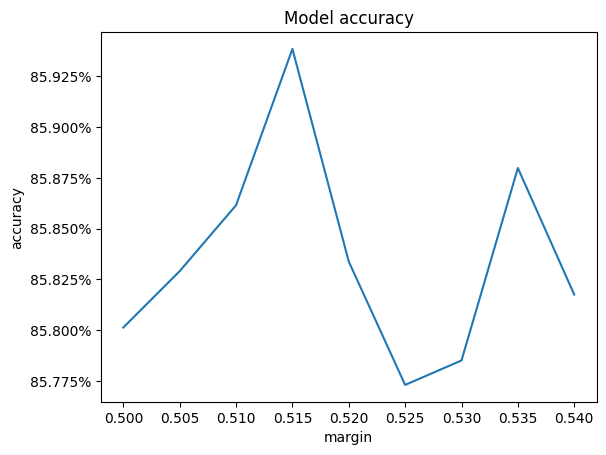

In [24]:
def plot_model(history, margins, accuracies):
    if history: 
        fig, (ax1, ax2) = plt.subplots(2)
    else: fig, ax1 = plt.subplots(1)

    ax1.plot(margins, accuracies)
    ax1.set_title("Model accuracy")
    ax1.set_ylabel("accuracy")
    ax1.set_xlabel("margin")
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

    if history:
        ax2.plot(history.history["loss"], label="Train")
        ax2.plot(history.history["val_loss"], label="Dev")
        ax2.set_title("Loss")
        ax2.set_ylabel("loss")
        ax2.set_xlabel("epoch")
        ax2.legend()

    plt.show()

plot_model(history, margins, accuracies)

#### Download

In [25]:
from IPython.display import FileLink

audio_cnn.save("audio_cnn.keras")
display(FileLink("audio_cnn.keras"))


/Volumes/Dafna/venv-tf/audio_cnn.keras

### 1D CNN on Spectrogram

In [14]:
spectro_shape = LogMelSpectrogram(sample_rate=sample_rate).compute_output_shape((batch_size,) + audio_input_shape)

spect_1d = keras.Sequential([
  layers.Input(shape=audio_input_shape),
  LogMelSpectrogram(sample_rate=sample_rate),
  layers.Normalization(),
  # The width dimension represents time, and the height represents frequencies.
  # We treat the frequencies as "features", so we can convolve over them.
  layers.Reshape((spectro_shape[1], spectro_shape[2])),
  layers.Conv1D(spectro_shape[2], 3, activation="relu", padding="same"),
  layers.BatchNormalization(),
  layers.MaxPooling1D(),
  layers.Conv1D(256, 3, activation="relu", padding="same"),
  layers.BatchNormalization(),
  layers.MaxPooling1D(),
  layers.Conv1D(256, 3, activation="relu", padding="same"),
  layers.Conv1D(512, 3, activation="relu", padding="same"),
  layers.BatchNormalization(),
  layers.MaxPooling1D(),
  layers.Conv1D(1024, 3, activation="relu", padding="same"),
  layers.BatchNormalization(),
  layers.MaxPooling1D(),
  layers.Conv1D(1024, 3, activation="relu", padding="same"),
  layers.BatchNormalization(),
  layers.MaxPooling1D(),
  layers.Conv1D(4096, 3, activation="relu", padding="same"),
  layers.BatchNormalization(),
  layers.MaxPooling1D(),

  layers.Flatten(),
  layers.Dense(4096, activation="relu"),
  layers.Dropout(0.2),
  layers.Dense(2048, activation="relu"),
  L2Normalize(),
], name="cnn_1d_spectro")

spect_1d.summary()

Model: "cnn_1d_spectro"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ log_mel_spectrogram_5           │ (None, 243, 64, 1)     │             0 │
│ (LogMelSpectrogram)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_2 (Normalization) │ (None, 243, 64, 1)     │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 243, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 243, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 243, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 121, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 121, 256)       │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 121, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 60, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_18 (Conv1D)              │ (None, 60, 256)        │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 60, 512)        │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 60, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 30, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_20 (Conv1D)              │ (None, 30, 1024)       │     1,573,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 30, 1024)       │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 15, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 15, 1024)       │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 15, 1024)       │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_16 (MaxPooling1D) │ (None, 7, 1024)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_22 (Conv1D)              │ (None, 7, 4096)        │    12,587,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 7, 4096)        │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 76,714,307 (292.64 MB)

 Trainable params: 76,700,352 (292.59 MB)

 Non-trainable params: 13,955 (54.52 KB)

In [ ]:
siamese_spect_1d = siamese_from_model(spect_1d, audio_input_shape)

siamese_spect_1d.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4), loss=contrastive_loss(margin=1.0))
history = siamese_spect_1d.fit(
    train_ds,
    epochs=30,
    callbacks=callbacks,
    validation_data=dev_ds,
)

Epoch 1/30


2026-03-21 15:05:00.722691: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  35/1177 ━━━━━━━━━━━━━━━━━━━━ 12:52 676ms/step - loss: 0.3877

### 2D CNN on Spectrogram (Mobilenet)

In [85]:
mobilenet = keras.Sequential([
    layers.Input(shape=audio_input_shape),
    LogMelSpectrogram(sample_rate=sample_rate),
    keras.applications.MobileNetV2(input_shape=spectro_shape[1:], include_top=False, weights=None),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(2048),
    L2Normalize(),
])

mobilenet.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ log_mel_spectrogram_28          │ (None, 243, 64, 1)     │             0 │
│ (LogMelSpectrogram)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_243            │ (None, 8, 2, 1280)     │     2,257,408 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 20480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 20480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2048)           │    41,945,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalize_3 (L2Normalize)    │ (None, 2048)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,202,496 (168.62 MB)

 Trainable params: 44,168,384 (168.49 MB)

 Non-trainable params: 34,112 (133.25 KB)

### 2D Bespoke CNN on Spectrogram

In [ ]:
spect_2d = keras.Sequential([
  layers.Input(shape=spectrogram_shape),
  layers.Normalization(),
  layers.Conv2D(32, 3, activation="relu", padding="same"),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, activation="relu", padding="same"),
  layers.BatchNormalization(),
  layers.MaxPooling2D(),
  layers.Conv2D(128, 3, activation="relu", padding="same"),
  layers.Conv2D(256, 3, activation="relu", padding="same"),
  layers.BatchNormalization(),
  layers.MaxPooling2D(),
  layers.Conv2D(256, 3, activation="relu", padding="same"),
  layers.BatchNormalization(),
  layers.MaxPooling2D(),
  layers.Conv2D(256, 3, activation="relu", padding="same"),
  layers.BatchNormalization(),
  layers.MaxPooling2D(),
  layers.Conv2D(512, 3, activation="relu", padding="same"),
  layers.BatchNormalization(),
  layers.MaxPooling2D(),
  layers.Conv2D(1024, 3, activation="relu", padding="same"),
  layers.BatchNormalization(),
  layers.MaxPooling2D(),

  layers.Flatten(),
  layers.Dense(4096, activation="relu"),
  layers.Dropout(0.2),
  layers.Dense(2048, activation="relu"),
  layers.BatchNormalization(),
], name="2D CNN on Spectrogram")

spect_2d.summary()

Model: "2D CNN on Spectrogram"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 256, 512, 1)    │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 512, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 256, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 128, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 128, 256)   │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64, 128, 256)   │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 16, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 16, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 16, 512)     │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 8, 16, 512)     │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 8, 1024)     │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 4, 8, 1024)     │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 4, 1024)     │             

 Total params: 49,434,627 (188.58 MB)

 Trainable params: 49,425,792 (188.54 MB)

 Non-trainable params: 8,835 (34.52 KB)